[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HumbertoDiego/AjustamentoAvancadoIME/blob/main/06_otimizacao.ipynb)

# Aula 6 - Otimização

**Maj Diego - 1º Semestre / 2027**

**Objetivos:**

1. Formular função objetivo e função de custo.
2. Comparar métodos diretos e métodos de gradiente.
3. Implementar otimização em lotes e mini-batches e preparar a 5ª VE prática.

## 1. Função objetivo e custo

**A função de perda (*loss function*) retorna um escalar: $\mathcal{L}(X)\in\mathbb{R}$.**

- O objetivo da otimização é encontrar $\underset{X}{argmin} \ \mathcal{L}$;
- $X$ no contexto do ajustamento são os parâmetros ajustado ou $X_a$;
- Um primeiro passo para construir uma boa função de perda é definir um vetor de erros, no contexto do ajustamento, definimos os resíduos $V=F(X)-L$, os quais queremos minimizar;

$$
V = Ajustado - Observado
$$

- No contexto da ciência de dados, em geral:
$$
V = real - predito \\
V = Ground Truth - Modelo \\
$$

- A função de perda passa a ser uma sintetização representativa do vetor dos resíduos.

Nas expressões abaixo, $\Sigma_L=\operatorname{diag}(\sigma_i^2)$ é a matriz de covariância das observações, $\Sigma_L^{1/2}=\operatorname{diag}(\sigma_i)$ é a matriz de desvios padrões das observações e $P=\Sigma_L^{-1}$ são os pesos ($P=I$ para desconsiderar a importância relativa entre observações). As observações são consideradas independentes, e $\mathbf{1}_m$ é o vetor de uns.

- **Perda absoluta:**
  $$\mathcal{L}_1(X)=\frac1m\mathbf{1}_m^T\left|\Sigma_L^{-1/2}V\right|$$

  Sem ponderação, obtém-se o $MAE$ nas unidades dos resíduos: $\frac1m\mathbf{1}_m^T|V|$.

- **Perda quadrática:**
  $$\mathcal{L}_2(X)=\frac{1}{m}V^T\Sigma_L^{-1}V$$

  Sem ponderação, obtém-se o $MSE$: $\frac{1}{m}V^TV$.

  Na unidade dos resíduos podemos calcular o $RMSE = \sqrt{MSE}$

- **Perda de Huber:**

  A perda média para o vetor de resíduos $\mathbf{V}$ é expressa por:

  $$\mathcal{L}_\delta(\mathbf{V}) = \frac{1}{n} \sum_{i=1}^{n} l_\delta(v_i)$$

  Onde a função de custo aplicada a cada componente $v_i$ do vetor é:

$$l_\delta(v_i) = \begin{cases} \frac{1}{2} v_i^2 & \text{se } \vert{}v_i\vert{} \le \delta \\ \delta \left(\vert{}v_i\vert{} - \frac{1}{2}\delta\right) & \text{se } \vert{}v_i\vert{} > \delta \end{cases}$$

- **Ridge — regularização L2:**
  $$\mathcal{L}_{ridge}(X)=\frac{1}{2m}V^T\Sigma_L^{-1}V+\underbrace{\frac{\lambda^2}{2}X^TX}_{\text{penalização Ridge (L2)}}$$
  No modelo linear, $V=AX-L$. A penalização favorece parâmetros menores e pode introduzir viés. Para regularizar correções em relação a cotas aproximadas, substitua $X^TX$ por $(X-X_{ref})^T(X-X_{ref})$.


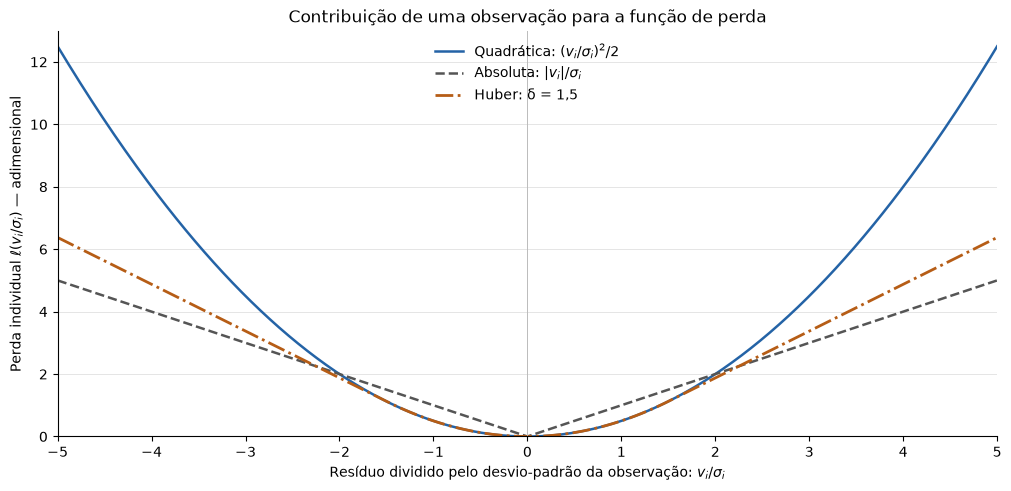

In [1]:
# Comparação das contribuições individuais das funções de perda
import numpy as np
import matplotlib.pyplot as plt

def perda_huber(V, delta=1.5, sigma=1.0):
    V = np.asarray(V,dtype=float)
    return np.where(np.abs(V/sigma) <= delta, 0.5*(V/sigma)**2,
                    delta*(np.abs(V/sigma)-0.5*delta))

# Escala ilustrativa; o eixo mostra explicitamente v_i / sigma_i.
perdas_sigma = 1.0
perdas_V = np.linspace(-5,5,501)*perdas_sigma
perdas_delta = 1.5

assert np.allclose(
    perda_huber([0.5,1.,4.],perdas_delta,perdas_sigma),[0.125,0.5,4.875]
)

with plt.rc_context({
    "font.size":10,"axes.titlesize":12,"figure.facecolor":"white",
    "axes.facecolor":"white","axes.spines.top":False,"axes.spines.right":False,
}):
    perdas_fig,perdas_ax=plt.subplots(figsize=(10,4.8),constrained_layout=True)
    perdas_ax.plot(perdas_V/perdas_sigma,0.5*(perdas_V/perdas_sigma)**2,
                    color="#2463A6",lw=1.8,label=r"Quadrática: $(v_i/\sigma_i)^2/2$")
    perdas_ax.plot(perdas_V/perdas_sigma,np.abs(perdas_V/perdas_sigma),
                    color="#555555",lw=1.8,ls="--",label=r"Absoluta: $|v_i|/\sigma_i$")
    perdas_ax.plot(perdas_V/perdas_sigma,perda_huber(perdas_V,perdas_delta,perdas_sigma),
                    color="#B65D16",lw=2,ls="-.",label="Huber: δ = 1,5")
    perdas_ax.set(
        title="Contribuição de uma observação para a função de perda",
        xlabel=r"Resíduo dividido pelo desvio-padrão da observação: $v_i/\sigma_i$",
        ylabel=r"Perda individual $\ell(v_i/\sigma_i)$ — adimensional",
        xlim=(-5,5),ylim=(0,13),xticks=np.arange(-5,6),
    )
    perdas_ax.axvline(0,color="#BBBBBB",lw=.7)
    perdas_ax.grid(axis="y",color="#E0E0E0",lw=.6)
    perdas_ax.legend(frameon=False,loc="upper center")
    plt.show()


## 2. Solução direta, métodos sem derivadas e gradiente

A **solução direta de MMQ** resolve o problema linear por uma fatoração, como QR ou SVD, sem percorrer épocas de treinamento. Um **método sem derivadas**, como Powell ou Nelder–Mead, é iterativo e busca reduzir a função objetivo usando avaliações de seu valor. Em alguns textos, esses algoritmos também são chamados de métodos de busca direta; aqui, essa expressão não deve ser confundida com a solução algébrica de MMQ.

Os **métodos de gradiente** usam $\nabla \mathcal{L}$ para atualizar os parâmetros e dependem do passo e do condicionamento. Para compará-los de forma consistente, mantenha o mesmo problema, a mesma escala da função objetivo e as mesmas unidades.

In [2]:
import numpy as np

A = np.array([[1.,0.],[1.,1.],[1.,2.],[1.,3.]])
L = np.array([1.,2.,2.8,4.2])
X = np.zeros(2)
eta = 0.05
for _ in range(200):
    G = A.T @ (A @ X - L) / len(L)
    X -= eta * G
print('Gradiente:', X)
print('Solução direta:', np.linalg.lstsq(A, L, rcond=None)[0])

Gradiente: [0.92144766 1.04868945]
Solução direta: [0.94 1.04]


## 3. Lotes, mini-batches e épocas

No *batch gradient descent*, todo o conjunto compõe o gradiente. No método estocástico ou por mini-batches, atualizações mais frequentes reduzem custo por passo e introduzem variabilidade. Em todos os casos, embaralhamento e reprodutibilidade devem ser controlados.

## 5ª VE prática

Comparar solução direta, método sem derivadas e gradiente em um mesmo problema. Relatar custo por iteração, critério de parada, sensibilidade ao passo e resultado final.

### Dados e questão — otimização de uma rede altimétrica

Uma equipe executa **30 séries independentes de nivelamento** em uma rede de cinco marcos A, B, C, D e E. Cada série observa as mesmas oito ligações da tabela, totalizando **240 desníveis**. Admita que as altitudes sejam constantes durante a campanha e que todas as observações estejam no mesmo referencial. Os dados são **simulados para fins didáticos**, com ruído gaussiano independente e semente **2027**.

A é a referência fixa, com $h_A=150{,}000\,\mathrm{m}$. As demais altitudes devem ser estimadas a partir das cotas aproximadas:

| Marco | A (fixo) | B | C | D | E |
|---|---:|---:|---:|---:|---:|
| Cota aproximada H⁰ (m) | 150,000 | 181,500 | 174,200 | 205,700 | 197,400 |

| Ligação | Desnível segundo H⁰ (m) | Desvio-padrão de cada observação (mm) | Repetições |
|---|---:|---:|---:|
| A → B | +31,500 | 2 | 30 |
| B → C | −7,300 | 3 | 30 |
| C → D | +31,500 | 2 | 30 |
| D → E | −8,300 | 4 | 30 |
| E → A | −47,400 | 3 | 30 |
| A → C | +24,200 | 2 | 30 |
| B → D | +24,200 | 3 | 30 |
| C → E | +23,200 | 5 | 30 |

A célula seguinte gera as **240 observações individuais**, sem substituí-las por médias. As médias por ligação servem apenas para apresentar os dados. Os valores exibidos são arredondados para leitura; os cálculos usam os arrays completos.

**Parâmetros, modelo e função objetivo**

Estime $X=[\delta h_B,\delta h_C,\delta h_D,\delta h_E]^T$ em **mm**, partindo de $X^{(0)}=0$. A altitude final é $h_j=h_j^0+\delta h_j/1000$ em metros. Para uma observação de i para j:

$$l_{ij}=1000\,[\Delta h_{ij}^{obs}-(h_j^0-h_i^0)],\qquad L+V=AX.$$

O termo escalar $l_{ij}$ integra o vetor L de observações reduzidas. Monte A com −1 para o marco de partida e +1 para o de chegada, omitindo a coluna de A. A função objetivo será a **média dos custos ponderados**:

$$\mathcal{L}(X)=\frac{1}{2m}(AX-L)^TP(AX-L)\in\mathbb{R},\qquad m=240.$$

$$\nabla \mathcal{L}(X)=\frac{1}{m}A^TP(AX-L),\qquad
P=\Sigma_L^{-1},\qquad \Sigma_L=\operatorname{diag}(\sigma_i^2).$$

Todas as grandezas dentro dos resíduos estão em mm. O fator $1/m$ não altera o minimizador do MMQ, mas altera a escala do gradiente e do passo; mantenha essa convenção em todos os algoritmos.

Para um mini-batch B, use a média sobre suas observações:

$$G_B(X)=\frac{1}{|B|}A_B^TP_B(A_BX-L_B),$$

em que $A_B$, $L_B$ e $P_B$ contêm apenas as observações selecionadas para o lote.

Uma **época** é uma passagem por todas as 240 observações. Embaralhe os índices a cada época usando semente controlada. Use o tamanho real do último lote na média.

| Estratégia | Observações por atualização | Atualizações por época |
|---|---:|---:|
| Gradiente em lote completo | 240 | 1 |
| Mini-batch | 64 | 4: lotes de 64, 64, 64 e 48 |
| Mini-batch | 16 | 15 |
| Gradiente estocástico | 1 | 240 |

**O que responder na 5ª VE**

1. Apresente o modelo, a função objetivo e seu gradiente. Confira o posto da matriz e a determinação das quatro correções.
2. Obtenha a referência numérica por MMQ ponderado, usando QR ou SVD. Depois minimize a mesma função com um método sem derivadas, como Powell ou Nelder–Mead, partindo das mesmas cotas aproximadas.
3. Implemente gradiente em lote completo e investigue a sensibilidade ao passo. Para a função quadrática definida, calcule o maior autovalor da Hessiana e compare passos abaixo, próximos e acima de $2/\lambda_{\max}$. Registre convergência, oscilação ou divergência.
4. Compare lotes de 240, 64, 16 e 1 observação. Use até 500 épocas e, nos métodos estocásticos, compare passo constante com uma regra decrescente documentada. A condição de estabilidade do lote completo não garante estabilidade para todos os mini-batches.
5. Declare tolerâncias e critérios de parada. Nos métodos estocásticos, avalie o custo completo ao final das épocas e considere a variabilidade; um lote isolado com gradiente pequeno não comprova convergência do problema inteiro.
6. Mostre o custo completo versus épocas e versus trabalho computacional: número de avaliações da função/gradiente e de observações processadas. Separe o custo de monitoramento e não compare uma iteração de Powell com uma época de gradiente como se fossem operações equivalentes.
7. Compare altitudes finais, resíduos, custo e diferença em relação à solução de MMQ. Interprete as diferenças numéricas sem atribuí-las a movimentos físicos dos marcos.

**Dados disponíveis após executar a célula:** ve5_dados contém as observações e seus identificadores; ve5_A, ve5_L, ve5_S e ve5_Sigma_L definem o problema; ve5_X0 fornece o ponto inicial. As funções ve5_custo, ve5_gradiente e ve5_minibatches permitem usar exatamente os mesmos dados e a mesma normalização em todas as comparações. As cotas verdadeiras usadas na simulação servem apenas para conferir os resultados depois dos ajustes.


,quantidade,media_desnivel_m,sigma_individual_mm
Ligação,,,
A → B,30,31.525344,2.0
B → C,30,-7.342815,3.0
C → D,30,31.553289,2.0
D → E,30,-8.347911,4.0
E → A,30,-47.387509,3.0
A → C,30,24.182047,2.0
B → D,30,24.210936,3.0
C → E,30,23.205670,5.0


Primeira série; as 240 observações estão em ve5_dados:


,Série,Ligação,Desnível observado (m),σ (mm),Termo reduzido l_i (mm)
ID,,,,,
1,1,A → B,31.525222,2.0,25.222
2,1,B → C,-7.343251,3.0,-43.251
3,1,C → D,31.551392,2.0,51.392
4,1,D → E,-8.355609,4.0,-55.609
5,1,E → A,-47.384364,3.0,15.636
6,1,A → C,24.181036,2.0,-18.964
7,1,B → D,24.209416,3.0,9.416
8,1,C → E,23.201586,5.0,1.586


Observações: 240 | incógnitas: 4 | graus de liberdade: 236
Custo no ponto inicial: 83.671794
Lotes de 64 em uma época: [64, 64, 64, 48]
As médias acima são um resumo; use as 240 observações nos algoritmos.


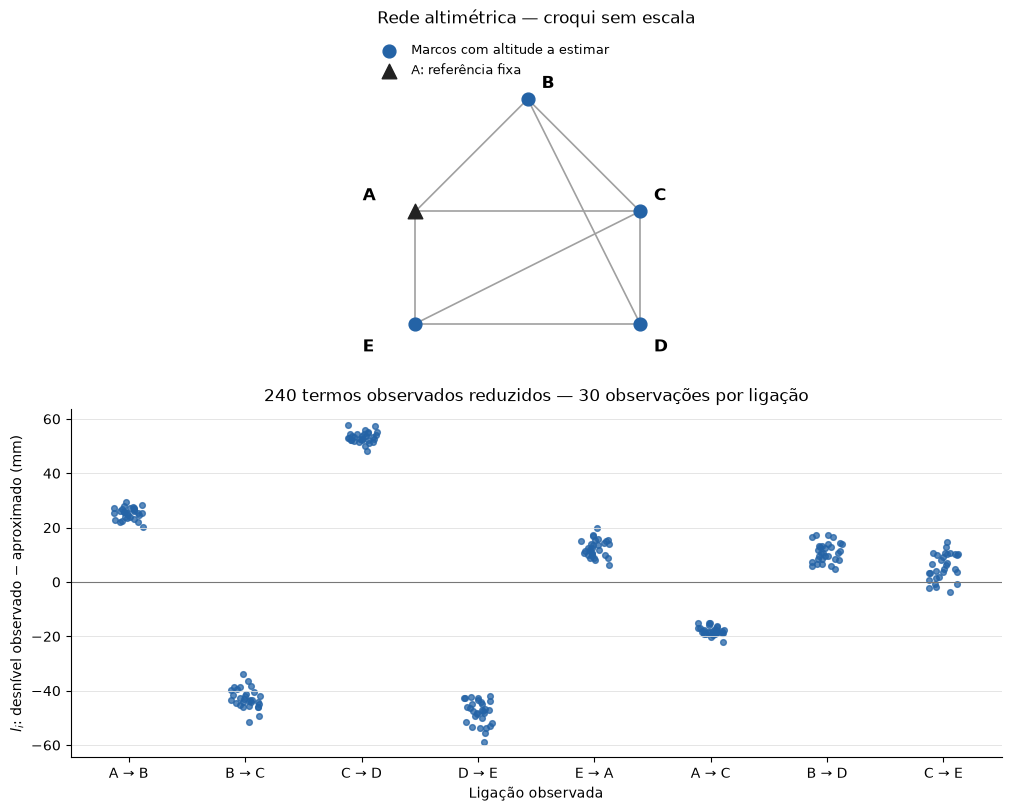

In [3]:
# Dados simulados e funções de apoio à 5ª VE prática
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ve5_semente = 2027
ve5_rng = np.random.default_rng(ve5_semente)
ve5_marcos = np.array(list("ABCDE"))
ve5_H0 = np.array([150., 181.5, 174.2, 205.7, 197.4])  # m
ve5_ligacoes = [(0,1),(1,2),(2,3),(3,4),(4,0),(0,2),(1,3),(2,4)]
ve5_S_ligacoes = np.array([2.,3.,2.,4.,3.,2.,3.,5.])  # mm
ve5_repeticoes = 30
ve5_X0 = np.zeros(4)  # correções iniciais, em mm

# Referência usada para simular, não como entrada dos otimizadores.
ve5_X_verdade = np.array([25., -18., 35., -12.])  # B, C, D, E, em mm
ve5_H_verdade = ve5_H0.copy()
ve5_H_verdade[1:] += ve5_X_verdade/1000

ve5_A_base = np.zeros((len(ve5_ligacoes),4))
for ve5_i, (ve5_de, ve5_para) in enumerate(ve5_ligacoes):
    if ve5_de != 0:
        ve5_A_base[ve5_i,ve5_de-1] = -1
    if ve5_para != 0:
        ve5_A_base[ve5_i,ve5_para-1] = 1

# Cada série contém as oito ligações, sempre na ordem da tabela.
ve5_A = np.tile(ve5_A_base, (ve5_repeticoes,1))
ve5_S = np.tile(ve5_S_ligacoes,ve5_repeticoes)
ve5_Sigma_L = np.diag(ve5_S**2)  # covariância das observações, em mm²
ve5_ligacao_id = np.tile(np.arange(8),ve5_repeticoes)
ve5_serie = np.repeat(np.arange(1,ve5_repeticoes+1),8)
ve5_DH0_base = np.array([ve5_H0[j]-ve5_H0[i] for i,j in ve5_ligacoes])
ve5_DH0 = np.tile(ve5_DH0_base,ve5_repeticoes)
ve5_E = ve5_rng.normal(0,ve5_S)
ve5_L = ve5_A @ ve5_X_verdade + ve5_E
ve5_DH_observado_m = ve5_DH0 + ve5_L/1000
ve5_m = len(ve5_L)

ve5_rotulos = [f"{ve5_marcos[i]} → {ve5_marcos[j]}" for i,j in ve5_ligacoes]
ve5_dados = pd.DataFrame({
    "ID": np.arange(1,ve5_m+1),
    "Série": ve5_serie,
    "Ligação": [ve5_rotulos[i] for i in ve5_ligacao_id],
    "Desnível observado (m)": ve5_DH_observado_m,
    "σ (mm)": ve5_S,
    "Termo reduzido l_i (mm)": ve5_L,
}).set_index("ID")

def ve5_custo(X, indices=None):
    """Custo médio ponderado, adimensional, no conjunto ou lote selecionado."""
    selecao = slice(None) if indices is None else np.asarray(indices, dtype=int)
    V = ve5_A[selecao] @ np.asarray(X) - ve5_L[selecao]
    return float(0.5*np.mean((V/ve5_S[selecao])**2))

def ve5_gradiente(X, indices=None):
    """Gradiente do mesmo custo médio; divide pelo tamanho real do lote."""
    selecao = slice(None) if indices is None else np.asarray(indices, dtype=int)
    A_B = ve5_A[selecao]
    V = A_B @ np.asarray(X) - ve5_L[selecao]
    return A_B.T @ (V/ve5_S[selecao]**2)/len(V)

def ve5_minibatches(tamanho=16, epoca=0, semente=2028):
    """Uma permutação reproduzível por época; sem reposição dentro da época."""
    if not isinstance(tamanho, (int,np.integer)) or not 1 <= tamanho <= ve5_m:
        raise ValueError("O tamanho do lote deve ser inteiro entre 1 e 240.")
    if epoca < 0:
        raise ValueError("A época deve ser não negativa.")
    rng_epoca = np.random.default_rng(np.random.SeedSequence([semente,epoca]))
    indices = rng_epoca.permutation(ve5_m)
    return [indices[i:i+tamanho] for i in range(0,ve5_m,tamanho)]

# Mantém as observações individuais para batch, mini-batch e SGD.
ve5_resumo = ve5_dados.groupby("Ligação",sort=False).agg(
    quantidade=("Série","size"),
    media_desnivel_m=("Desnível observado (m)","mean"),
    sigma_individual_mm=("σ (mm)","first"),
)
display(ve5_resumo.style.format({
    "media_desnivel_m":"{:.6f}", "sigma_individual_mm":"{:.1f}",
}))
print("Primeira série; as 240 observações estão em ve5_dados:")
display(ve5_dados.head(8).style.format({
    "Desnível observado (m)":"{:.6f}",
    "σ (mm)":"{:.1f}", "Termo reduzido l_i (mm)":"{:.3f}",
}))
print(f"Observações: {ve5_m} | incógnitas: 4 | graus de liberdade: {ve5_m-4}")
print(f"Custo no ponto inicial: {ve5_custo(ve5_X0):.6f}")
print("Lotes de 64 em uma época:", [len(b) for b in ve5_minibatches(64)])
print("As médias acima são um resumo; use as 240 observações nos algoritmos.")

# Verifica o preparo dos dados e a correspondência entre custo e gradiente.
ve5_Aw = ve5_A/ve5_S[:,None]
ve5_Hessiana = (ve5_Aw.T @ ve5_Aw)/ve5_m
assert np.linalg.matrix_rank(ve5_A) == 4
assert np.linalg.eigvalsh(ve5_Hessiana).min() > 0
assert np.allclose(1000*(ve5_DH_observado_m-ve5_DH0),ve5_L)
for ve5_b in (1,16,64,240):
    ve5_indices = np.concatenate(ve5_minibatches(ve5_b))
    assert np.array_equal(np.sort(ve5_indices),np.arange(ve5_m))
ve5_h = 1e-4
ve5_Base = np.eye(4)*ve5_h
ve5_G_fd = np.array([
    (ve5_custo(ve5_X0+D)-ve5_custo(ve5_X0-D))/(2*ve5_h)
    for D in ve5_Base
])
assert np.allclose(ve5_G_fd,ve5_gradiente(ve5_X0),rtol=1e-7,atol=1e-8)

# Croqui esquemático e observações reduzidas; não são resultados de ajuste.
with plt.rc_context({
    "font.size":10,"axes.titlesize":12,"figure.facecolor":"white",
    "axes.facecolor":"white","axes.spines.top":False,"axes.spines.right":False,
}):
    ve5_fig, ve5_axes = plt.subplots(2,1,figsize=(10,8),constrained_layout=True)
    ve5_XY = np.array([[0.,0.],[1.,1.],[2.,0.],[2.,-1.],[0.,-1.]])
    ax = ve5_axes[0]
    for i,j in ve5_ligacoes:
        ax.plot(ve5_XY[[i,j],0],ve5_XY[[i,j],1],color="#A0A0A0",lw=1.2,zorder=1)
    ax.scatter(ve5_XY[1:,0],ve5_XY[1:,1],s=85,color="#2463A6",zorder=3,
               label="Marcos com altitude a estimar")
    ax.scatter(ve5_XY[0,0],ve5_XY[0,1],s=110,color="#222222",marker="^",zorder=3,
               label="A: referência fixa")
    ve5_offsets = [(-38,8),(10,8),(10,8),(10,-20),(-38,-20)]
    for i,nome in enumerate(ve5_marcos):
        ax.annotate(nome,ve5_XY[i],xytext=ve5_offsets[i],textcoords="offset points",
                    fontsize=12,fontweight="bold")
    ax.set(title="Rede altimétrica — croqui sem escala",xlim=(-.45,2.6),ylim=(-1.5,1.6))
    ax.set_aspect("equal")
    ax.axis("off")
    ax.legend(loc="upper left",frameon=False,fontsize=9)

    ax = ve5_axes[1]
    ve5_jitter = np.random.default_rng(2029).uniform(-.13,.13,ve5_m)
    ax.scatter(ve5_ligacao_id+ve5_jitter,ve5_L,s=17,color="#2463A6",alpha=.75)
    ax.axhline(0,color="#777777",lw=.8)
    ax.set(title="240 termos observados reduzidos — 30 observações por ligação",
           xlabel="Ligação observada",ylabel=r"$l_i$: desnível observado − aproximado (mm)",
           xticks=np.arange(8),xticklabels=ve5_rotulos,xlim=(-.5,7.5))
    ax.grid(axis="y",color="#E0E0E0",lw=.6)
    plt.show()
